# Day 20: Applied Probability & Statistics through Simulation

Welcome to Day 20! Today is all about making abstract probability concepts concrete by writing code to simulate them. We will be exploring four core pillars of probability and statistics:

- **The Law of Large Numbers:** Observing how randomness stabilizes over large samples.
- **Probability Distributions:** Visualizing how individual random events combine into predictable patterns.
- **Conditional Probability:** Calculating odds based on subsets of data.
- **Bayes' Theorem & The Base Rate Fallacy:** Understanding how rare a condition is fundamentally changes the interpretation of a test for it.

---
### Today's Tasks:
* Simulate 10,000 coin flips with NumPy (`np.random.randint(0, 2, 10000)`). Confirm the proportion of heads approaches 0.5 — the law of large numbers in action.
* Simulate rolling two dice 10,000 times; plot a histogram of the sums. Notice 7 is most common — your first taste of a distribution emerging from simple rules.
* Compute a simple conditional probability on the Titanic data: `P(survived | female)` vs `P(survived | male)`. You already did the groupby for this on Day 11 — now you have the name for what you computed.
* The disease-test simulation (the big one): imagine a disease affecting 1% of people and a test that's 99% accurate. Simulate 100,000 people, apply the test, and compute: of everyone who tested positive, what fraction actually have the disease? Be surprised by the answer (~50%, not 99%). This is Bayes' theorem made concrete.

In [1]:
import numpy as np

# Simulate 10,000 coin flips (0 for tails, 1 for heads)
flips = np.random.randint(0, 2, 10000)

# Calculate the proportion of heads
proportion_heads = flips.mean()
print(f"Proportion of heads: {proportion_heads:.4f}")

Proportion of heads: 0.5038


### 1. The Law of Large Numbers (Coin Flips)
**The Concept:** The **Law of Large Numbers** is a fundamental theorem in statistics. It states that as the number of identically distributed, randomly generated variables increases, their sample mean (average) will get closer and closer to their theoretical expected value. 
* **Why it matters:** If you flip a coin 10 times, you might easily get 7 heads (70%). But if you flip it 10,000 times, the randomness "evens out," and the proportion of heads will tightly converge to the true theoretical probability of 50%.

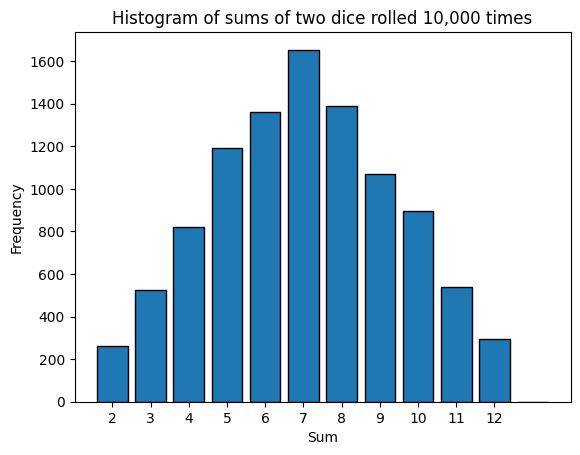

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate rolling two dice 10,000 times
die1 = np.random.randint(1, 7, 10000)
die2 = np.random.randint(1, 7, 10000)
sums = die1 + die2

# Plot a histogram of the sums
plt.hist(sums, bins=range(2, 15), align='left', rwidth=0.8, edgecolor='black')
plt.title('Histogram of sums of two dice rolled 10,000 times')
plt.xlabel('Sum')
plt.ylabel('Frequency')
plt.xticks(range(2, 13))
plt.show()

### 2. Probability Distributions (Rolling Two Dice)
**The Concept:** While rolling a *single* fair die gives you a **Uniform Distribution** (you have an equal $\frac{1}{6}$ chance of rolling any number 1 through 6), adding *two* dice together creates a completely different pattern. 
* **Why it matters:** The number 7 is the most common result because there are 6 different combinations that add up to 7 (1+6, 2+5, 3+4, 4+3, 5+2, 6+1). Conversely, there is only one way to roll a 2 (1+1) or a 12 (6+6). The histogram you plotted visually demonstrates how combining multiple independent uniform events starts building a bell-like curve (a nod towards the Central Limit Theorem).

In [3]:
import pandas as pd
import seaborn as sns

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Compute P(survived | female) and P(survived | male)
survival_rates = titanic.groupby('sex')['survived'].mean()
print("P(survived | female):", survival_rates['female'])
print("P(survived | male):", survival_rates['male'])

P(survived | female): 0.7420382165605095
P(survived | male): 0.18890814558058924


### 3. Conditional Probability (Titanic Dataset)
**The Concept:** **Conditional Probability** measures the probability of an event occurring, *given that* another event has already occurred. It is denoted as $P(A | B)$, read as "the probability of A given B".
* **Why it matters:** Instead of looking at the overall survival rate of everyone on the Titanic, you are restricting your "universe" (the denominator) to just females or just males. You are calculating: out of *only the females*, what fraction survived? It shows how sub-populations can have drastically different statistical behaviors from the overall population.

In [4]:
import numpy as np

n_people = 100000

# Disease affects 1% of people (1 for disease, 0 for no disease)
disease_status = np.random.choice([1, 0], size=n_people, p=[0.01, 0.99])

# Test is 99% accurate
random_probs = np.random.rand(n_people)
test_results = np.where(disease_status == 1, 
                        random_probs < 0.99,  # 99% True Positive Rate
                        random_probs < 0.01)  # 1% False Positive Rate

# Fraction of people who tested positive that actually have the disease
disease_given_positive = disease_status[test_results].mean()

print(f"Fraction of people with positive tests who actually have the disease: {disease_given_positive:.4f}")

Fraction of people with positive tests who actually have the disease: 0.5081


### 4. Bayes' Theorem and The Base Rate Fallacy (Disease Simulation)
**The Concept:** This is the most counter-intuitive concept here, often called the **Base Rate Fallacy**. It relies on **Bayes' Theorem**, which describes how to update the probabilities of hypotheses when given new evidence (like a test result).
* **Why it matters (~50% vs 99%):** You would intuitively think that if a test is 99% accurate, a positive result means you are 99% likely to have the disease. However, you must account for the *base rate* (the disease only affects 1% of the population). 
* **The Math:** In a population of 100,000 people:
  * **1,000 people actually have the disease** (1%). The test correctly flags 99% of them = **990 True Positives**.
  * **99,000 people are healthy** (99%). The test incorrectly flags 1% of them = **990 False Positives**.
  * If you get a positive test, you are among the $990 + 990 = 1,980$ people who tested positive. Because the false positives equal the true positives, a positive test means there is only a roughly 50% chance ($990 / 1980$) you actually have the disease!